### Round 1 Analysis - INTARIAN_PEPPER_ROOT

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
from sklearn.linear_model import LinearRegression


import prosperity4
from prosperity4.utils.dataloader import (
    load_trading_data,
    get_product_data,
    get_day_data,
    get_product_day_data,
    get_price_data,
    get_order_book_data,
    get_volume_data,
    convert_timestamp,
)


plt.style.use("dark_background")
sns.set_palette("pastel")

### Data Loading

In [2]:
REPO_ROOT = Path(prosperity4.__file__).parents[1]
DATA_FOLDER = REPO_ROOT / "prosperity4" / "round1" / "data"
ROUND_NUM = 1
DAYS = [-2, -1, 0]

data = load_trading_data(DATA_FOLDER, ROUND_NUM, DAYS)
prices_df = data.get("prices")
trades_df = data.get("trades")

print("Prices Shape :", prices_df.shape if prices_df is not None else None)
print("Trades Shape :", trades_df.shape if trades_df is not None else None)
print("\n--- Prices Head ---")
display(prices_df.head())
print("\n--- Trades Head ---")
display(trades_df.head())

Prices Shape : (60000, 17)
Trades Shape : (2276, 8)

--- Prices Head ---


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0



--- Trades Head ---


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6,-2
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2,-2
2,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7,-2
3,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8,-2
4,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7,-2


### Splitting the datasets based on the products

In [3]:
products = prices_df["product"].unique()

pepper_prices_df = prices_df[prices_df["product"] == "INTARIAN_PEPPER_ROOT"]
pepper_trades_df = trades_df[trades_df["symbol"] == "INTARIAN_PEPPER_ROOT"]

In [4]:
'''
Here we are copying the original dataframes, removing the buyer, seller and currency from the trades, summing if there are orders at the
same timestamp and price, then renaming the price and quantity column to market order price and quantity so we know these are bots trades,
then we are merging the 2 datasets so we have all the data on prices and volume, if at that timestamp there's a bot's trade, there's also the 
data for these trades.
At the end we are converting the timestamps so we have timestamp as index
'''

pepper_trades = pepper_trades_df.copy()

# Grouping and merging the EMERALDS so we only have 1 dataset containing both prices and trades, sorted by timestamp
pepper_trades = pepper_trades.drop(columns = ["buyer", "seller", "currency"])
pepper_trades = pepper_trades.groupby(["timestamp", "price", "day"], as_index = False).agg({"quantity": "sum"})
pepper_trades = pepper_trades.rename(columns = { 
                                        "price": "market order price",
                                        "quantity": "market order quantity"})
pepper = pepper_prices_df.merge(pepper_trades[["timestamp", "market order price", "market order quantity", "day"]],
                                on = ["timestamp", "day"],
                                how = "left")

# Convert to continuous timeframe so we don't have 2 separate days
pepper = convert_timestamp(pepper)

pepper.head()


,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,market order price,market order quantity,t
0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,NaN,NaN,-3000000
1,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,NaN,NaN,-2999900
2,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0,NaN,NaN,-2999800
3,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,10006.0,10.0,10008.0,21.0,NaN,NaN,10006.0,0.0,NaN,NaN,-2999700
4,INTARIAN_PEPPER_ROOT,9992.0,20.0,NaN,NaN,NaN,NaN,10006.0,12.0,10008.0,20.0,NaN,NaN,9999.0,0.0,NaN,NaN,-2999600


# Price and Trades plots

C:\Users\marco\AppData\Local\Temp\ipykernel_27284\1618422473.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


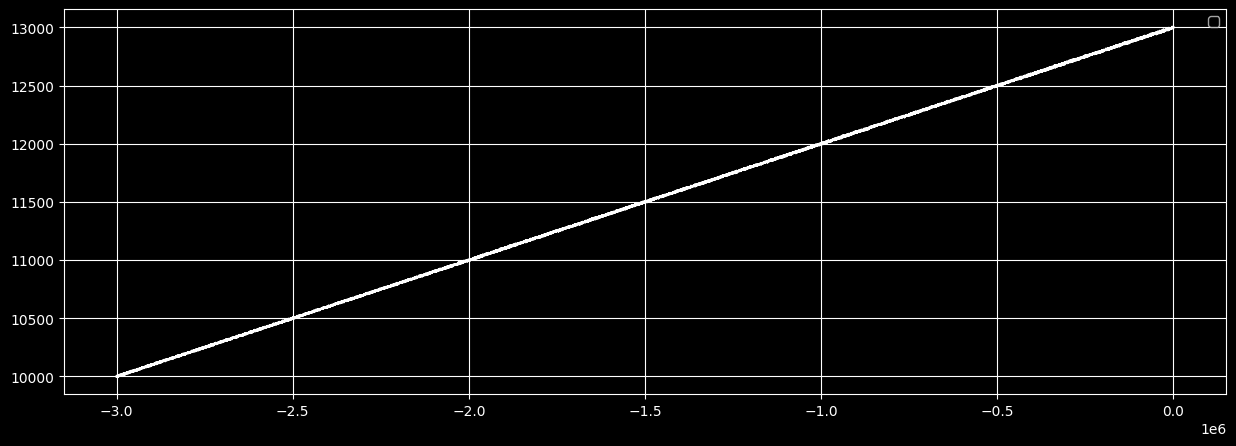

In [5]:
# PLOTS OF PRICES
plt.figure(figsize = (15,5))
plt.plot(pepper["t"], pepper["mid_price"].replace(0, np.nan), color = "white")
plt.grid(True)
plt.legend()
plt.show()

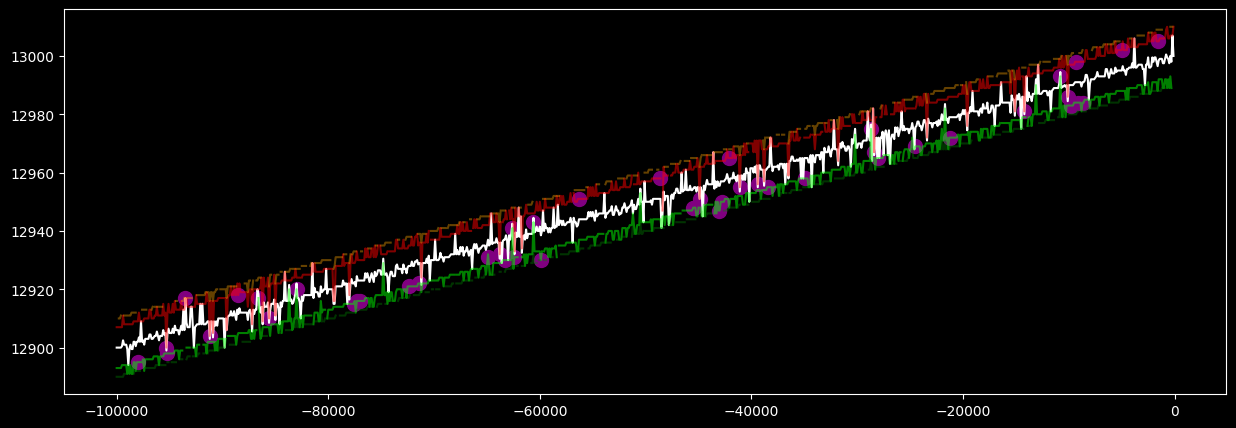

In [6]:
# This considers the mid price
plt.figure(figsize=(15,5))
plt.plot(pepper["t"][-1000:], pepper["mid_price"][-1000:].replace(0, np.nan), color = "white", alpha = 1)
plt.plot(pepper["t"][-1000:], pepper["ask_price_1"][-1000:].replace(0, np.nan), color = "red", alpha = 0.5)
plt.plot(pepper["t"][-1000:], pepper["ask_price_2"][-1000:].replace(0, np.nan), color = "orange", alpha = 0.4)
plt.plot(pepper["t"][-1000:], pepper["ask_price_3"][-1000:].replace(0, np.nan), color = "salmon", alpha = 0.3)
plt.plot(pepper["t"][-1000:], pepper["bid_price_1"][-1000:].replace(0, np.nan), color = "lime", alpha = 0.5)
plt.plot(pepper["t"][-1000:], pepper["bid_price_2"][-1000:].replace(0, np.nan), color = "green", alpha = 0.4)
plt.plot(pepper["t"][-1000:], pepper["bid_price_3"][-1000:].replace(0, np.nan), color = "darkgreen", alpha = 0.4)
plt.scatter(pepper["t"][-1000:], pepper["market order price"][-1000:].replace(0, np.nan), color = "purple", alpha = 1, s = 100)
plt.show()

### Slope Analysis

We fit a straight line to the mid price over time, this is our "fair value" estimate.

The residual is how far the actual price is from this line at each moment.

Slope      : 0.001000  (price units per timestamp)
Intercept  : 13000.0048
R²         : 0.999994

Residual stats:
count    2.994800e+04
mean     7.227246e-13
std      2.201654e+00
min     -1.070457e+01
25%     -2.911337e-01
50%      3.940192e-03
75%      2.973636e-01
max      1.059608e+01
Name: residual, dtype: float64


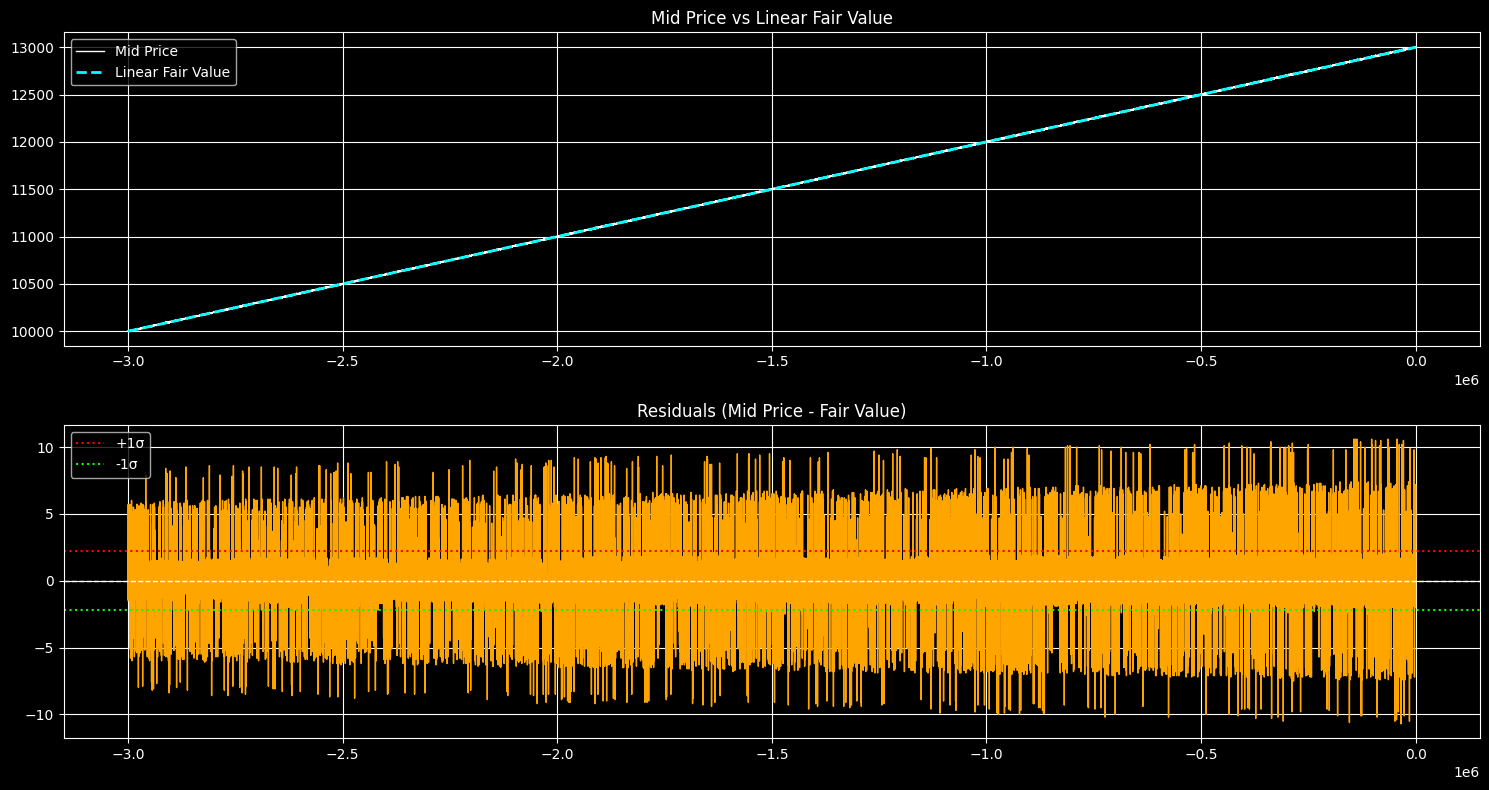

In [7]:
# Filter valid mid prices
valid = pepper[pepper["mid_price"] > 0].copy()

X = valid["t"].values.reshape(-1, 1)
y = valid["mid_price"].values

reg = LinearRegression().fit(X, y)
valid["fair_value"] = reg.predict(X)
valid["residual"] = valid["mid_price"] - valid["fair_value"]

slope = reg.coef_[0]
intercept = reg.intercept_

print(f"Slope      : {slope:.6f}  (price units per timestamp)")
print(f"Intercept  : {intercept:.4f}")
print(f"R²         : {reg.score(X, y):.6f}")
print(f"\nResidual stats:")
print(valid["residual"].describe())

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(valid["t"], valid["mid_price"], color="white", lw=1, label="Mid Price")
axes[0].plot(valid["t"], valid["fair_value"], color="cyan", lw=2, linestyle="--", label="Linear Fair Value")
axes[0].set_title("Mid Price vs Linear Fair Value")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(valid["t"], valid["residual"], color="orange", lw=1)
axes[1].axhline(0, color="white", linestyle="--", lw=1)
axes[1].axhline(valid["residual"].std(), color="red", linestyle=":", label="+1σ")
axes[1].axhline(-valid["residual"].std(), color="lime", linestyle=":", label="-1σ")
axes[1].set_title("Residuals (Mid Price - Fair Value)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Stationarity of residuals

Even though it's pretty obvious from the plots, we run a formal test to verify if residuals are stationary, which would imply that the series is mean-reverting.

Half-life value represents how many timestamps on average it takes for a deviation to halve. A short half-life means we can trade the fluctuations quickly and frequently.

=== Augmented Dickey-Fuller Test on Residuals ===
ADF Statistic : -120.6593
p-value       : 0.000000  ✓ Stationary


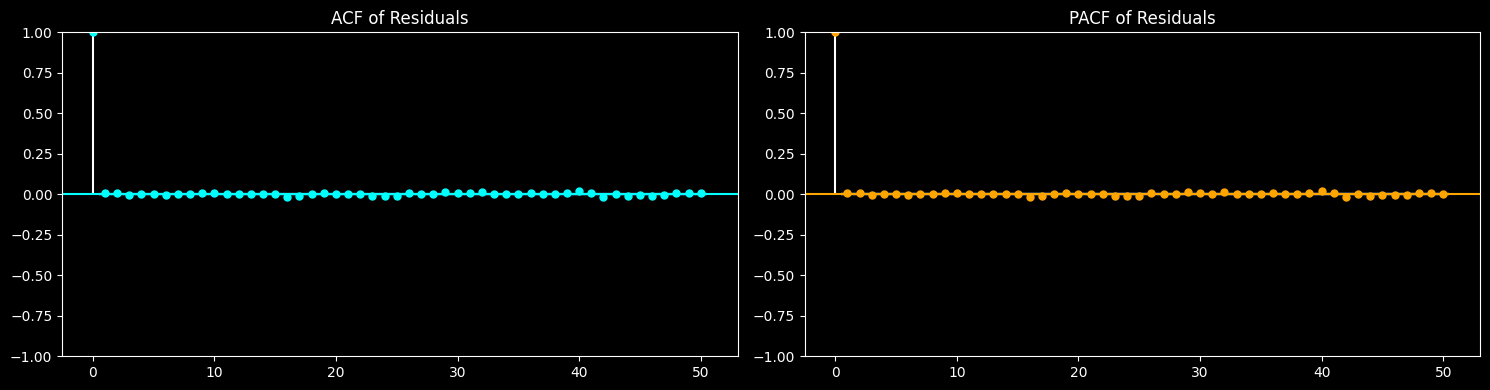


OU Mean-Reversion Speed (λ) : 0.991273
Half-life                   : 0.7 timestamps


In [8]:
# ADF test - is the residual stationary (mean-reverting)?
adf_result = adfuller(valid["residual"].dropna())
print("=== Augmented Dickey-Fuller Test on Residuals ===")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.6f}  {'✓ Stationary' if adf_result[1] < 0.05 else '✗ Non-stationary'}")

# ACF / PACF — reveals AR structure
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(valid["residual"].dropna(), lags=50, ax=axes[0], color="cyan")
plot_pacf(valid["residual"].dropna(), lags=50, ax=axes[1], color="orange")
axes[0].set_title("ACF of Residuals")
axes[1].set_title("PACF of Residuals")
plt.tight_layout()
plt.show()

# Half-life of mean reversion (Ornstein-Uhlenbeck estimate)
resid = valid["residual"].dropna().values
delta_resid = np.diff(resid)
lagged_resid = resid[:-1]

ou_reg = LinearRegression().fit(lagged_resid.reshape(-1,1), delta_resid)
lambda_ = -ou_reg.coef_[0]
half_life = np.log(2) / lambda_ if lambda_ > 0 else np.inf

print(f"\nOU Mean-Reversion Speed (λ) : {lambda_:.6f}")
print(f"Half-life                   : {half_life:.1f} timestamps")

### Market Orders Analysis

Now we analyze the behavior of market orders only.

What we are looking for:
* **Distribution (Histogram):** Are market orders clustered tightly around fair value, or are they scattered widely? This confirms how much margin we have to work with when placing our market-making quotes.
* **Context (Scatter Plot):** Do these extreme market orders happen randomly, or do they only occur when the mid-price is already heavily dislocated from the trend (high residual)?

Market orders count: 1009

Deviation of market orders from fair value:
count    1009.000000
mean       -0.580760
std         5.964878
min       -10.604073
25%        -6.095732
50%        -3.595529
75%         5.811198
max        10.495780
Name: mo_deviation, dtype: float64


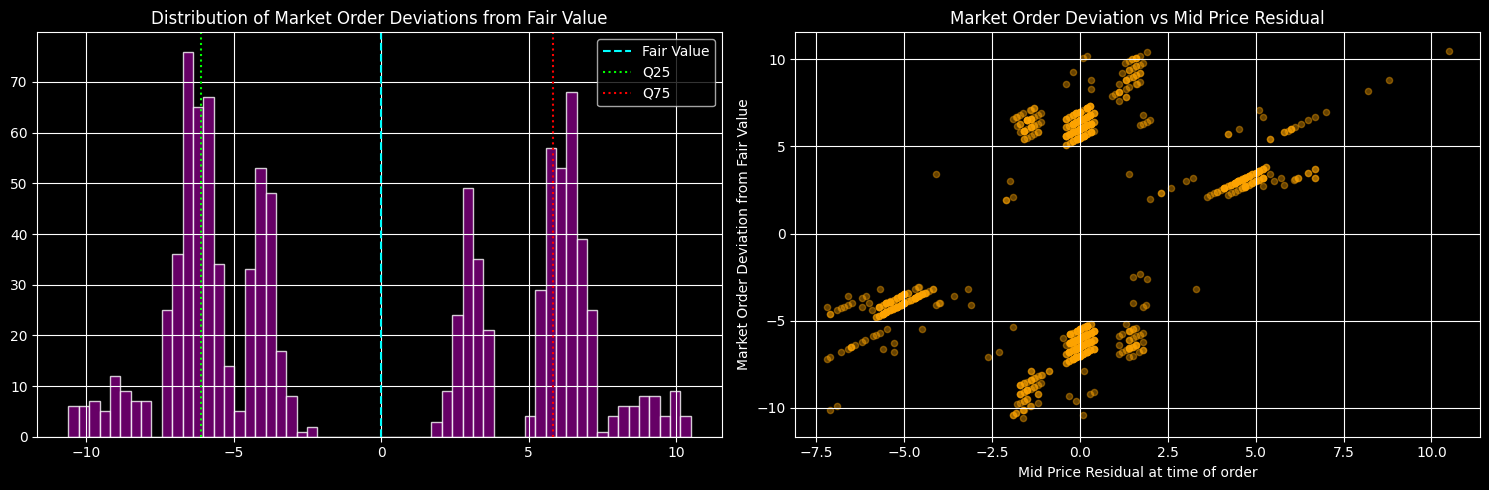

In [9]:
# Only rows where a market order actually occurred
mo = valid[valid["market order price"].notna()].copy()
mo["mo_deviation"] = mo["market order price"] - mo["fair_value"]

print(f"Market orders count: {len(mo)}")
print(f"\nDeviation of market orders from fair value:")
print(mo["mo_deviation"].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(mo["mo_deviation"], bins=60, color="purple", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="cyan", linestyle="--", label="Fair Value")
axes[0].axvline(mo["mo_deviation"].quantile(0.25), color="lime", linestyle=":", label="Q25")
axes[0].axvline(mo["mo_deviation"].quantile(0.75), color="red", linestyle=":", label="Q75")
axes[0].set_title("Distribution of Market Order Deviations from Fair Value")
axes[0].legend()
axes[0].grid(True)

# Deviation vs residual: are market orders hitting when mid_price is already dislocated?
axes[1].scatter(mo["residual"], mo["mo_deviation"], alpha=0.4, color="orange", s=20)
axes[1].axhline(0, color="white", lw=0.5)
axes[1].axvline(0, color="white", lw=0.5)
axes[1].set_xlabel("Mid Price Residual at time of order")
axes[1].set_ylabel("Market Order Deviation from Fair Value")
axes[1].set_title("Market Order Deviation vs Mid Price Residual")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Position Sizing

To allocate capital between the trend and mm strategies, we calculate the rolling maximum drawdown of the residuals. This quantifies our maximum adverse excursion risk. 

By measuring the worst historical drop (`max_adverse`) against normal volatility (`residual_std`), we can cap the allocation to mm strategy. This ensures the market-making book has enough inventory space to absorb standard 2σ deviations without hitting our hard 80-unit limit and shutting down.

=== Residual Drawdown Analysis ===
Max upside deviation  : 10.5961
Max downside deviation: -10.7046
Std of residual       : 2.2016
Max drawdown          : -21.3006

=== Suggested Position Split (limit=80) ===
Trend (buy & hold)      : 48.0 units
Fluctuation trading     : 32.0 units


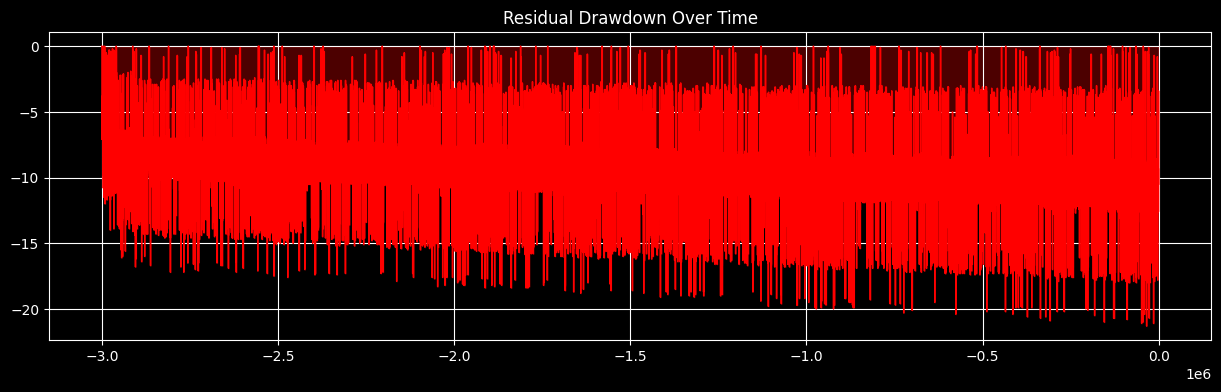

In [28]:
# Rolling max drawdown of residual — tells you max position at risk for fluctuation trading
residual = valid["residual"].values
rolling_max = np.maximum.accumulate(residual)
drawdown = residual - rolling_max

print("=== Residual Drawdown Analysis ===")
print(f"Max upside deviation  : {residual.max():.4f}")
print(f"Max downside deviation: {residual.min():.4f}")
print(f"Std of residual       : {residual.std():.4f}")
print(f"Max drawdown          : {drawdown.min():.4f}")

# Suggested position split logic
POSITION_LIMIT = 80

# Reserve enough to absorb worst-case residual move without margin call
# Use 1.5x the max observed drawdown as a buffer
max_adverse = abs(residual.min())
residual_std = residual.std()

# Size fluctuation book so 1 full position covers std_to_cover*σ move
# Hard cap: the fluctuation book will never be given more than 40% of the total portfolio (32 units)
std_to_cover = 2
fluctuation_allocation = min(POSITION_LIMIT * 0.4, POSITION_LIMIT * (std_to_cover * residual_std / max_adverse))
trend_allocation = POSITION_LIMIT - fluctuation_allocation

print(f"\n=== Suggested Position Split (limit={POSITION_LIMIT}) ===")
print(f"Trend (buy & hold)      : {trend_allocation:.1f} units")
print(f"Fluctuation trading     : {fluctuation_allocation:.1f} units")

# Plot drawdown
plt.figure(figsize=(15, 4))
plt.plot(valid["t"], drawdown, color="red", lw=1)
plt.fill_between(valid["t"], drawdown, 0, alpha=0.3, color="red")
plt.title("Residual Drawdown Over Time")
plt.grid(True)
plt.show()

### Order Book spread and depth analysis

In [ ]:
# Spread at best bid/ask
valid["spread"] = valid["ask_price_1"] - valid["bid_price_1"]

print("=== Bid-Ask Spread ===")
print(valid["spread"].describe())
print(f"\nMode spread : {valid['spread'].mode()[0]}")

# How far each ask/bid level is from mid price (typical depth structure)
for i in [1, 2, 3]:
    valid[f"ask_{i}_dist"] = valid[f"ask_price_{i}"] - valid["mid_price"]
    valid[f"bid_{i}_dist"] = valid["mid_price"] - valid[f"bid_price_{i}"]

print("\n=== Distance of each ask level from mid ===")
for i in [1, 2, 3]:
    col = f"ask_{i}_dist"
    print(f"  Ask {i}: mean={valid[col].mean():.2f}, median={valid[col].median():.2f}")

print("\n=== Distance of each bid level from mid ===")
for i in [1, 2, 3]:
    col = f"bid_{i}_dist"
    print(f"  Bid {i}: mean={valid[col].mean():.2f}, median={valid[col].median():.2f}")

# Volume at each level
print("\n=== Ask volume at each level ===")
for i in [1, 2, 3]:
    col = f"ask_volume_{i}"
    if col in valid.columns:
        print(f"  Ask {i}: mean={valid[col].mean():.1f}, total={valid[col].sum():.0f}")

print("\n=== Bid volume at each level ===")
for i in [1, 2, 3]:
    col = f"bid_volume_{i}"
    if col in valid.columns:
        print(f"  Bid {i}: mean={valid[col].mean():.1f}, total={valid[col].sum():.0f}")

=== Bid-Ask Spread ===
count    27690.000000
mean        13.045937
std          2.628582
min          2.000000
25%         12.000000
50%         13.000000
75%         14.000000
max         21.000000
Name: spread, dtype: float64

Mode spread : 13.0

=== Distance of each ask level from mid ===
  Ask 1: mean=6.26, median=6.50
  Ask 2: mean=9.07, median=9.50
  Ask 3: mean=13.43, median=13.50

=== Distance of each bid level from mid ===
  Bid 1: mean=6.27, median=6.50
  Bid 2: mean=9.04, median=9.50
  Bid 3: mean=12.96, median=13.00

=== Ask volume at each level ===
  Ask 1: mean=11.5, total=332429
  Ask 2: mean=19.7, total=385100
  Ask 3: mean=19.9, total=9320

=== Bid volume at each level ===
  Bid 1: mean=11.5, total=332308
  Bid 2: mean=19.7, total=383072
  Bid 3: mean=20.1, total=8938
